/tmp/ipython-input-2925208398.py:38: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  root = sqrtm(inner)
/tmp/ipython-input-2925208398.py:35: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  sr = sqrtm(rho)


CWI/CRS curves stored in DataFrame `df_cwi_all`.


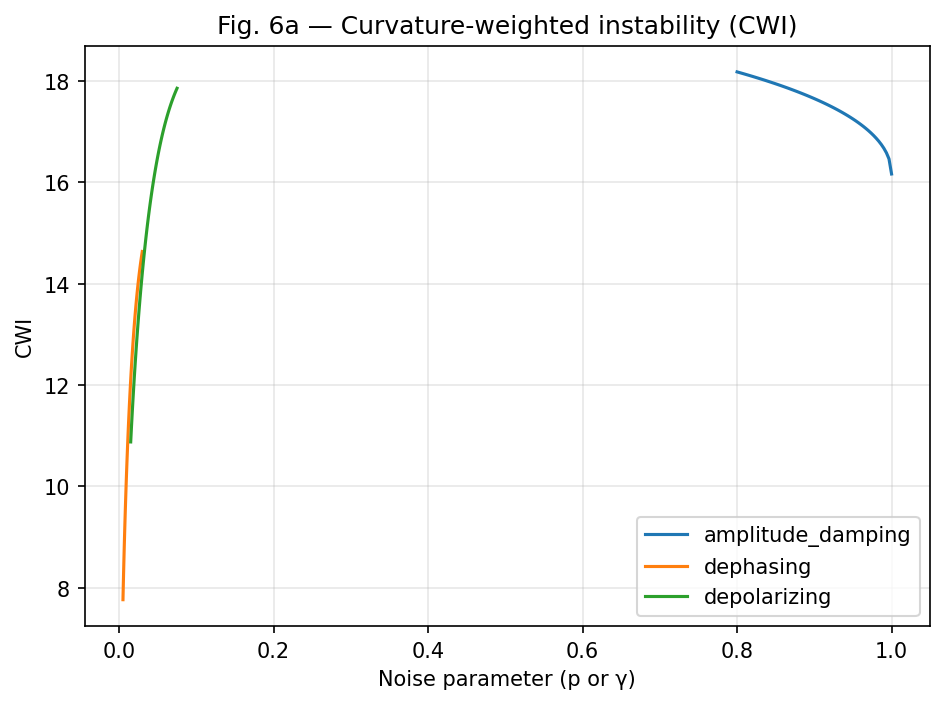

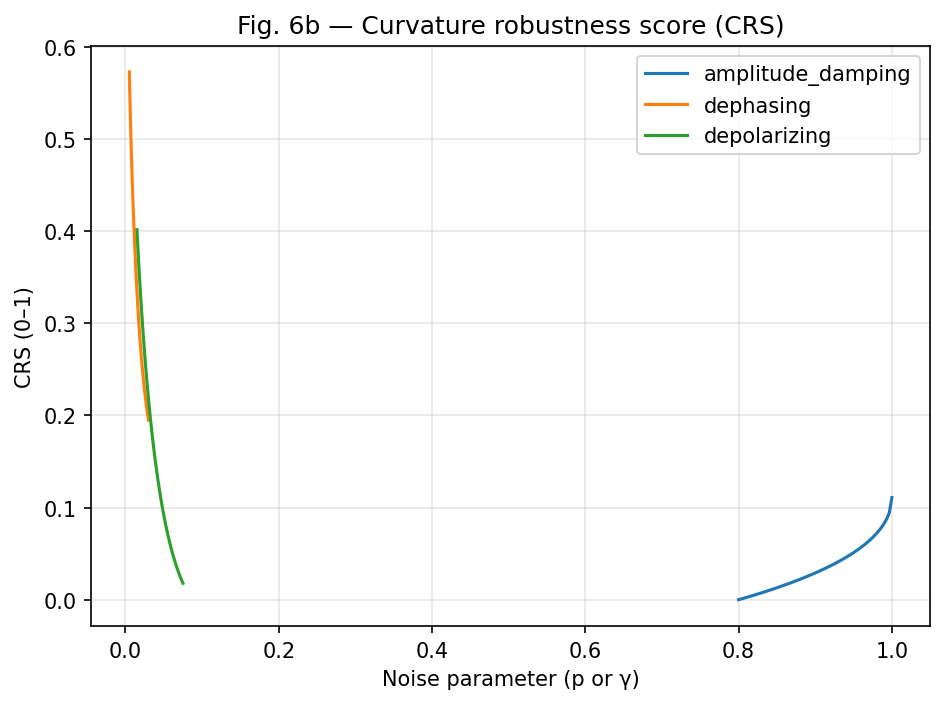

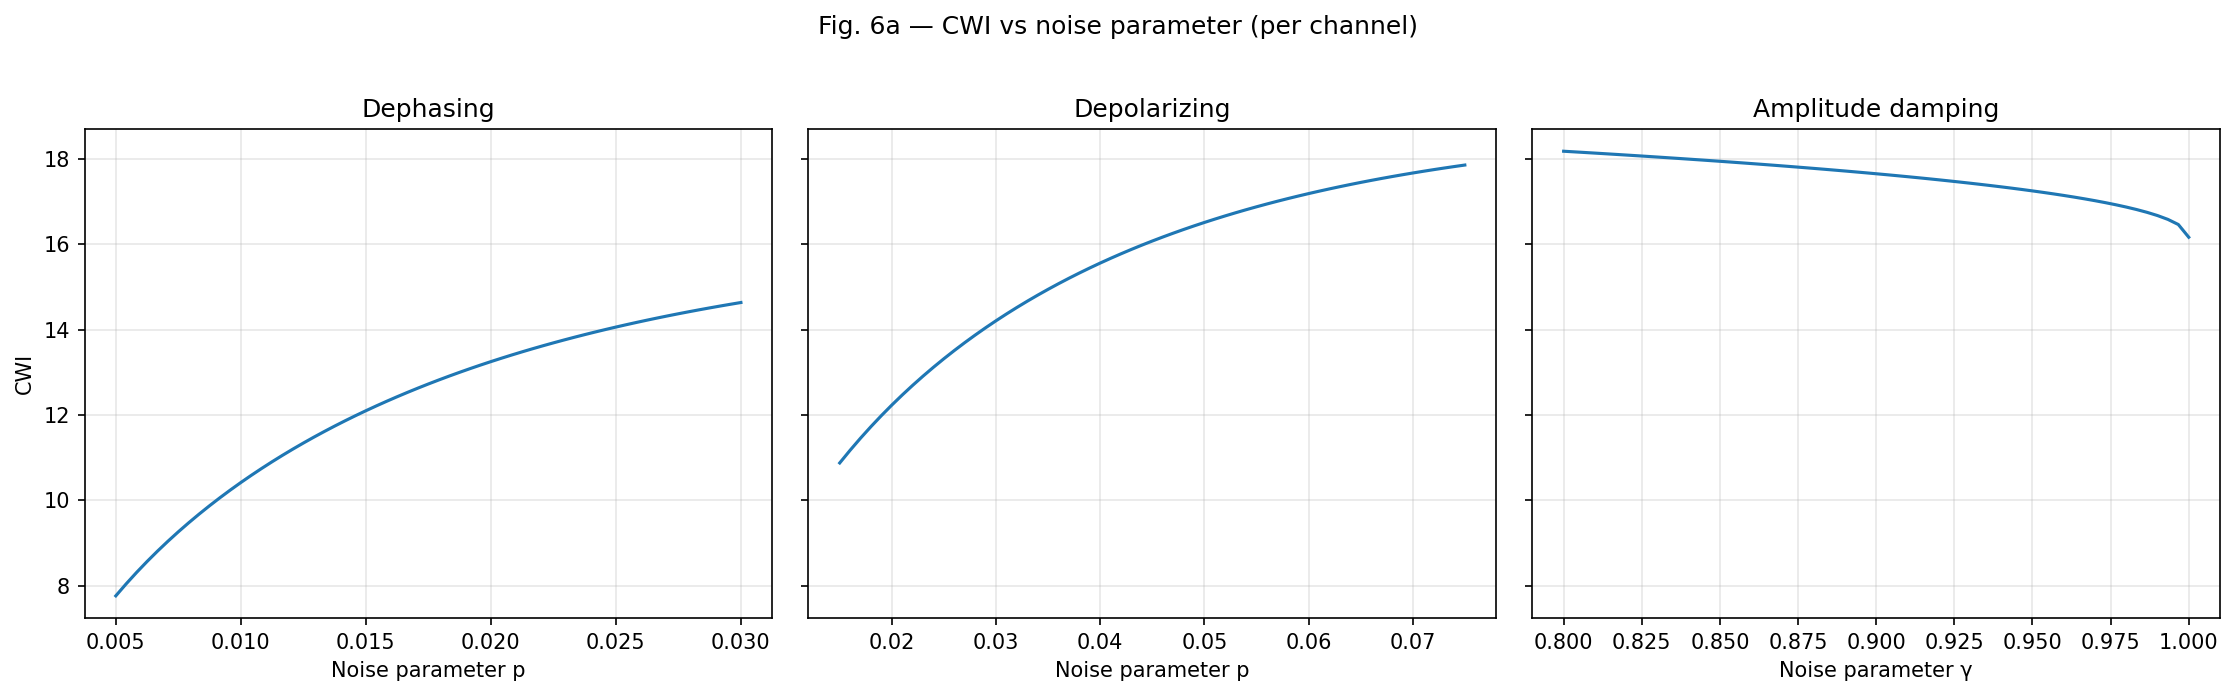

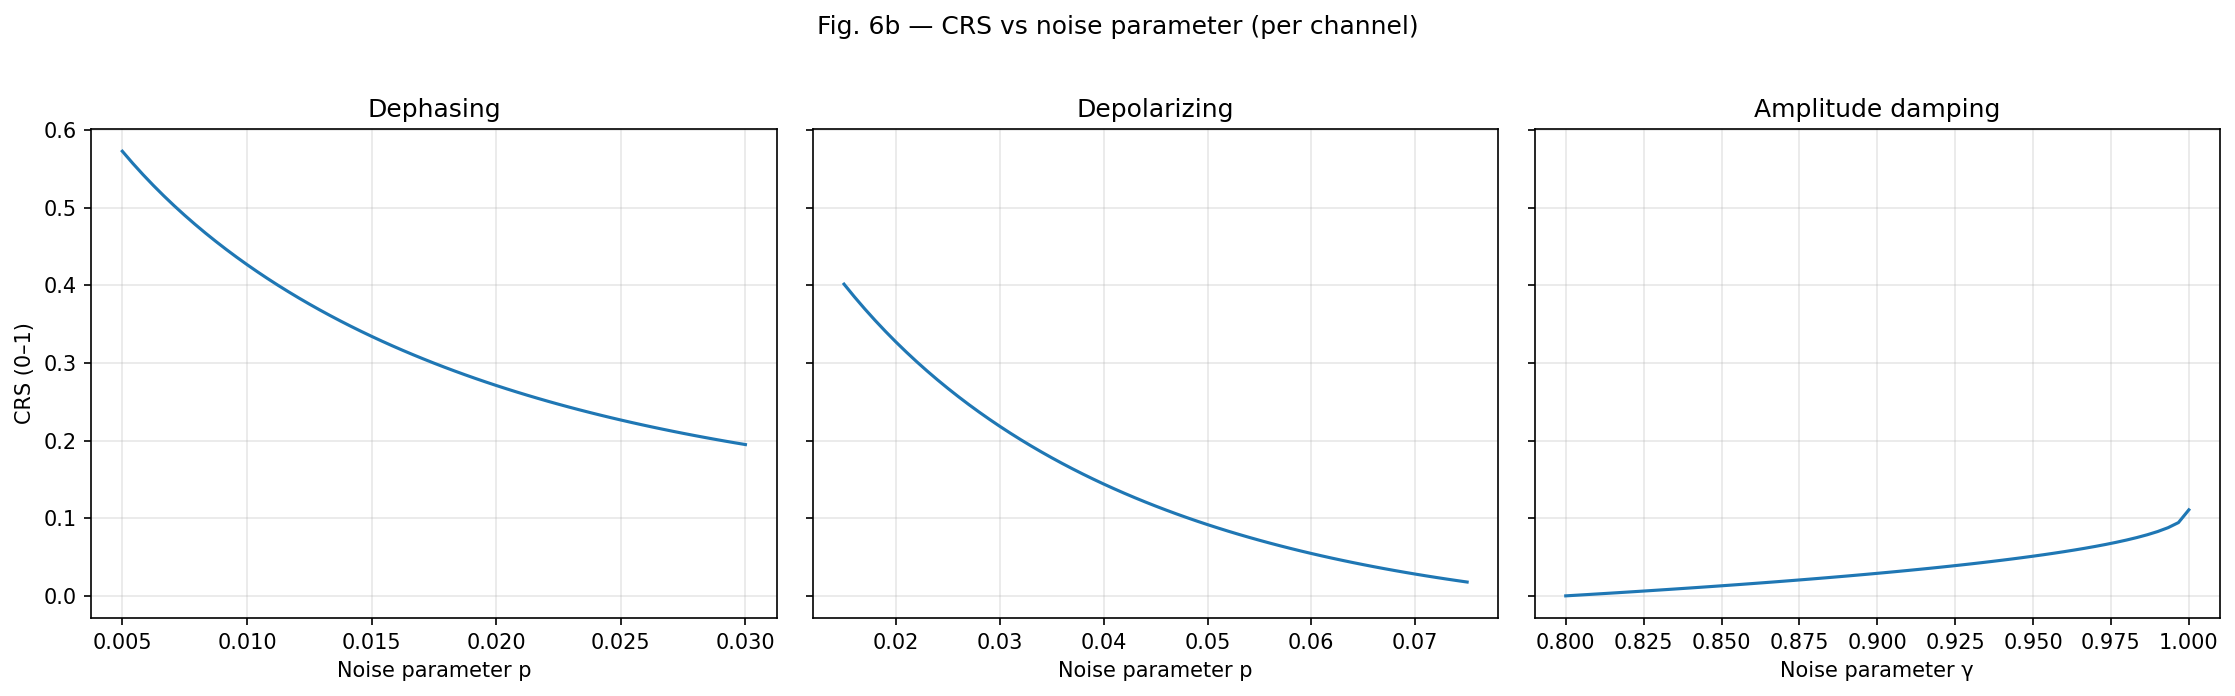

Tab. 4-style summary stored in DataFrame `tab4`:
             channel level   param   LB_mean   CWI_mean  CRS_mean
0  amplitude_damping   low  0.8200  0.753507  18.084165  0.004900
1  amplitude_damping   mid  0.9000  0.735253  17.646060  0.029007
2  amplitude_damping  high  0.9800  0.702780  16.866729  0.071891
3          dephasing   low  0.0075  0.386022   9.264532  0.490210
4          dephasing   mid  0.0175  0.530215  12.725169  0.299784
5          dephasing  high  0.0275  0.598705  14.368919  0.209335
6       depolarizing   low  0.0210  0.519469  12.467257  0.313976
7       depolarizing   mid  0.0450  0.669636  16.071262  0.115662
8       depolarizing  high  0.0690  0.734263  17.622306  0.030314


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import sqrtm

# -----------------------------
# Pauli matrices + identity
# -----------------------------
I2 = np.eye(2, dtype=np.complex128)
X  = np.array([[0, 1],[1, 0]], dtype=np.complex128)
Y  = np.array([[0, -1j],[1j, 0]], dtype=np.complex128)
Z  = np.array([[1, 0],[0, -1]], dtype=np.complex128)

# -----------------------------
# Basic utilities
# -----------------------------
def pure_to_rho(psi):
    """Return density matrix ρ = |ψ⟩⟨ψ| from a 2-component pure state."""
    psi = np.asarray(psi, dtype=np.complex128).reshape(2,1)
    psi = psi / np.linalg.norm(psi)
    return psi @ psi.conj().T

def haar_random_pure_qubit(n: int, seed: int = 42):
    """Generate n Haar-random pure qubit states (density matrices)."""
    rng = np.random.default_rng(seed)
    states = []
    for _ in range(n):
        z = rng.normal(size=2) + 1j * rng.normal(size=2)
        psi = z / np.linalg.norm(z)
        states.append(pure_to_rho(psi))
    return states

def fidelity(rho, sigma):
    """Uhlmann fidelity F(ρ, σ)."""
    sr = sqrtm(rho)
    inner = sr @ sigma @ sr
    inner = (inner + inner.conj().T) / 2.0  # numerical symmetrization
    root = sqrtm(inner)
    val = np.real(np.trace(root))**2
    return float(np.clip(val, 0.0, 1.0))

def bures_distance(rho, sigma):
    """Bures distance D_B(ρ, σ)."""
    F = fidelity(rho, sigma)
    return float(np.sqrt(max(0.0, 2.0*(1.0 - np.sqrt(F)))))

def apply_kraus(rho, Ks):
    """Apply a Kraus channel to ρ."""
    out = np.zeros((2,2), dtype=np.complex128)
    for K in Ks:
        out += K @ rho @ K.conj().T
    out = (out + out.conj().T) / 2.0
    tr = np.real(np.trace(out))
    return out / tr if tr != 0 else I2/2

# -----------------------------
# Channels (Kraus operators)
# -----------------------------
def dephasing_kraus(p):
    """Dephasing channel with parameter p."""
    return [np.sqrt(1-p)*I2, np.sqrt(p)*Z]

def depolarizing_kraus(p):
    """Depolarizing channel in Pauli form."""
    a0 = np.sqrt(1 - 3*p/4)
    a  = np.sqrt(p/4)
    return [a0*I2, a*X, a*Y, a*Z]

def amplitude_damping_kraus(g):
    """Amplitude damping channel with damping probability γ = g."""
    K0 = np.array([[1,0],[0,np.sqrt(1-g)]], dtype=np.complex128)
    K1 = np.array([[0,np.sqrt(g)],[0,0]], dtype=np.complex128)
    return [K0, K1]

# -----------------------------
# Trajectories and Bures length
# -----------------------------
def trajectory(rho0, Ks, depth):
    """Generate trajectory {ρ_k} by iterating the channel with fixed Kraus set Ks."""
    traj = [rho0]
    rho = rho0
    for _ in range(depth):
        rho = apply_kraus(rho, Ks)
        traj.append(rho)
    return traj

def trajectory_length_bures(traj):
    """Total Bures length L_B along the trajectory."""
    return sum(bures_distance(traj[i], traj[i+1]) for i in range(len(traj)-1))

# -----------------------------
# CWI / CRS definitions
# -----------------------------
R_ABS = 24.0   # conventional absolute scalar curvature for the qubit–Bures metric

def mean_CWI_over_states(kraus_fn, param, depth, n_random, seed=42):
    """
    Compute mean CWI and mean Bures length across Haar-random initial states
    for a fixed channel parameter.
    """
    states = haar_random_pure_qubit(n_random, seed=seed)
    Ks = kraus_fn(float(param))
    LBs = []
    for rho0 in states:
        traj = trajectory(rho0, Ks, depth)
        LBs.append(trajectory_length_bures(traj))
    LB_mean  = float(np.mean(LBs))
    CWI_mean = float(R_ABS * LB_mean)  # CWI ∝ L_B
    return CWI_mean, LB_mean

def sweep_CWI(channel_name, kraus_fn, grid, depth, n_random):
    """
    Sweep over the parameter grid, computing CWI and L_B means for each value.
    Returns a DataFrame with columns: channel, param, LB, CWI.
    """
    rows = []
    for param in grid:
        CWI_mean, LB_mean = mean_CWI_over_states(kraus_fn, param, depth, n_random)
        rows.append({
            "channel": channel_name,
            "param": float(param),
            "LB":    LB_mean,
            "CWI":   CWI_mean
        })
    return pd.DataFrame(rows)

# -----------------------------
# Experiment configuration
# -----------------------------
DEPTH    = 32
N_RANDOM = 24

# Parameter grids (p or γ depending on the channel)
grid_deph = np.linspace(0.005, 0.03, 61)   # p (dephasing)
grid_depo = np.linspace(0.015, 0.075, 61)  # p (depolarizing)
grid_ad   = np.linspace(0.80, 1.00, 61)    # γ (amplitude damping)

# -----------------------------
# Sweeps per channel and global CRS
# -----------------------------
df_cwi_deph = sweep_CWI("dephasing",         dephasing_kraus,         grid_deph, DEPTH, N_RANDOM)
df_cwi_depo = sweep_CWI("depolarizing",      depolarizing_kraus,      grid_depo, DEPTH, N_RANDOM)
df_cwi_ad   = sweep_CWI("amplitude_damping", amplitude_damping_kraus, grid_ad,   DEPTH, N_RANDOM)

# Full dataset
df_cwi_all = pd.concat([df_cwi_deph, df_cwi_depo, df_cwi_ad], ignore_index=True)

# Global normalization for CRS in [0,1]
CWI_max = df_cwi_all["CWI"].max()
df_cwi_all["CRS"] = 1.0 - (df_cwi_all["CWI"] / CWI_max)
df_cwi_all["CRS"] = df_cwi_all["CRS"].clip(0.0, 1.0)

print("CWI/CRS curves stored in DataFrame `df_cwi_all`.")

# -----------------------------
# Fig. 6a — CWI vs parameter (all channels together)
# -----------------------------
plt.figure()
for ch, dfc in df_cwi_all.groupby("channel"):
    d = dfc.sort_values("param")
    plt.plot(d["param"], d["CWI"], label=ch)
plt.xlabel("Noise parameter (p or γ)")
plt.ylabel("CWI")
plt.title("Fig. 6a — Curvature-weighted instability (CWI)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# Fig. 6b — CRS vs parameter (all channels together)
# -----------------------------
plt.figure()
for ch, dfc in df_cwi_all.groupby("channel"):
    d = dfc.sort_values("param")
    plt.plot(d["param"], d["CRS"], label=ch)
plt.xlabel("Noise parameter (p or γ)")
plt.ylabel("CRS (0–1)")
plt.title("Fig. 6b — Curvature robustness score (CRS)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# CWI panel — 1x3 subplots (one per channel)
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

channel_order = [
    ("dephasing",         "Dephasing",         "Noise parameter p"),
    ("depolarizing",      "Depolarizing",      "Noise parameter p"),
    ("amplitude_damping", "Amplitude damping", "Noise parameter γ"),
]

for j, (ch, title, xlabel) in enumerate(channel_order):
    d = df_cwi_all[df_cwi_all["channel"] == ch].sort_values("param")
    axes[j].plot(d["param"], d["CWI"])
    axes[j].set_title(title)
    axes[j].set_xlabel(xlabel)
    axes[j].grid(alpha=0.3)
    if j == 0:
        axes[j].set_ylabel("CWI")

fig.suptitle("Fig. 6a — CWI vs noise parameter (per channel)", y=1.02)
plt.tight_layout()
plt.show()

# -----------------------------
# CRS panel — 1x3 subplots (one per channel)
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

for j, (ch, title, xlabel) in enumerate(channel_order):
    d = df_cwi_all[df_cwi_all["channel"] == ch].sort_values("param")
    axes[j].plot(d["param"], d["CRS"])
    axes[j].set_title(title)
    axes[j].set_xlabel(xlabel)
    axes[j].grid(alpha=0.3)
    if j == 0:
        axes[j].set_ylabel("CRS (0–1)")

fig.suptitle("Fig. 6b — CRS vs noise parameter (per channel)", y=1.02)
plt.tight_layout()
plt.show()

# -----------------------------
# Tab. 4 — low/mid/high summary per channel
# -----------------------------
def pick_levels(df, levels=(0.1, 0.5, 0.9)):
    """
    Pick representative low/mid/high parameter values
    according to quantiles in [0,1] over the grid.
    Returns a DataFrame with columns: param, LB, CWI, CRS, level.
    """
    d = df.sort_values("param").reset_index(drop=True)
    idxs = [max(0, min(len(d)-1, int(round(q*(len(d)-1))))) for q in levels]
    return d.loc[idxs, ["param", "LB", "CWI", "CRS"]].assign(level=["low","mid","high"])

tab4_rows = []
for ch, dfc in df_cwi_all.groupby("channel"):
    sel = pick_levels(dfc)
    for _, r in sel.iterrows():
        tab4_rows.append({
            "channel": ch,
            "level":   r["level"],
            "param":   float(r["param"]),
            "LB_mean": float(r["LB"]),
            "CWI_mean":float(r["CWI"]),
            "CRS_mean":float(r["CRS"]),
        })

tab4 = pd.DataFrame(tab4_rows)

print("Tab. 4-style summary stored in DataFrame `tab4`:")
print(tab4)
